# A-RoF CMP-DPD

In [1]:
import sys

project_path = r"C:\Users\PC\Documents\Mestrado"
file_path    = project_path + r"\DPD"
sys.path.append(project_path)

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.signal             import welch, firwin, hilbert
from scipy.constants          import pi
from tqdm.notebook            import tqdm
from tabulate                 import tabulate

from optic.comm.ofdm          import modulateOFDM, demodulateOFDM
from optic.comm.modulation    import modulateGray
from optic.models.channels    import linearFiberChannel
from optic.models.devices     import mzm, photodiode
from optic.comm.metrics       import fastBERcalc, calcEVM
from optic.dsp.core           import pnorm, signal_power, upsample, pulseShape, decimate, finddelay
from optic.dsp.coreGPU        import firFilter
from optic.utils              import parameters, dBm2W
from optic_private.dsp.core   import calcACLR
from optic_private.torchUtils import fitFilterNN

from dpd.mp                   import CMP_filter, LS_CMP_solver
from dpd.utils                import power_amplifier, clip_complex
from dpd.plots                import calc_per_carrier

In [3]:
font = {'size':16}
plt.rc('font', **font)
plt.rcParams["font.family"] = "serif"

### 1 - Geração do Sinal OFDM

In [4]:
# Parâmetros de modulação
modOrder = 64                          # Ordem da modulação
modType  = 'qam'                       # Tipo de modulação
Rb = 5e9                               # Taxa de transmissão de bits
SpS = 32                               # Amostras por símbolo

# Parâmetros OFDM
paramOFDM = parameters()
paramOFDM.Nfft = 1024                  # Tam. da FFT
paramOFDM.G    = 32                    # Tam. do prefixo cíclico
paramOFDM.hermitSymmetry = False
paramOFDM.SpS = SpS
paramOFDM.returnChannel = False

if paramOFDM.hermitSymmetry:
    Ns = paramOFDM.Nfft//2 - 1
    paramOFDM.pilotCarriers = np.linspace(0, Ns - 1, 8, dtype = np.int64)
    paramOFDM.nullCarriers  = np.array([], dtype = np.int64)
else:
    Ns = paramOFDM.Nfft
    paramOFDM.pilotCarriers = np.linspace(0, Ns - 1, 8, dtype = np.int64)
    paramOFDM.nullCarriers  = np.array([paramOFDM.Nfft//2], dtype = np.int64)

# Núm. de subportadoras de informação
Np = paramOFDM.pilotCarriers.size
Nz = paramOFDM.nullCarriers.size
Ni = Ns - Np - Nz

Rs = Rb / ( Ni/(paramOFDM.Nfft + paramOFDM.G) * np.log2(modOrder) )    # Taxa de transmissão de símbolos
Fs = Rs * SpS                                                          # Taxa de amostragem

# Geração dos bits e dos símbolos QAM
numOFDMframes = 100
np.random.seed(2)
bits = np.random.randint(2, size = (numOFDMframes*Ni, int(np.log2(modOrder))))

symbTx = modulateGray(bits, modOrder, modType)
symbTx = pnorm(symbTx)

pilotSymb = 0.25*(max(symbTx.real) + 1j*max(symbTx.imag))
paramOFDM.pilot = pilotSymb

In [5]:
sigTx = modulateOFDM(symbTx, paramOFDM)
sigTx = pnorm(sigTx)

t = np.arange(0, sigTx.size)*1/Fs
t_CP   = SpS * paramOFDM.G * (1/Fs)
t_symb = SpS * (paramOFDM.Nfft + paramOFDM.G) * (1/Fs)

In [6]:
table = [['Grandeza', 'Parâmetro', 'Valor'],
         ['Taxa de amostragem', 'Fs', f'{Fs*1e-9:.2f} Gsamples/s'],
         ['Taxa de símbolos', 'Rs', f'{Rs*1e-9:.2f} Gsymb/s'],
         ['Taxa de transmissão', 'Rb', f'{Rb*1e-9:.2f} Gb/s'],
         ['Ordem da constelação', 'M', f'{modOrder}'],
         ['Tamanho da FFT', 'Nfft', f'{paramOFDM.Nfft}'],
         ['Tamanho do prefixo cíclico', 'G', f'{paramOFDM.G}'],
         ['Num. port. de informação', 'Ns', f'{Ni}'],
         ['Num. port. piloto', 'Np', f'{Np}'],
         ['Num. port. nulas', 'Nz', f'{Nz}'],
         ['Espaçamento entre subportadoras', 'Delta_f', f'{(Rs/paramOFDM.Nfft)*1e-6:.2f} MHz'],
         ['Duração do símbolo OFDM', 'T_symb', f'{1e9*t_symb:.2f} ns'],
         ['Duração do prefixo cíclico', 'T_CP', f'{1e9*t_CP:.2f} ns'] ]

print(tabulate(table, headers = 'firstrow', tablefmt = 'fancy_grid'))

╒═════════════════════════════════╤═════════════╤══════════════════╕
│ Grandeza                        │ Parâmetro   │ Valor            │
╞═════════════════════════════════╪═════════════╪══════════════════╡
│ Taxa de amostragem              │ Fs          │ 27.74 Gsamples/s │
├─────────────────────────────────┼─────────────┼──────────────────┤
│ Taxa de símbolos                │ Rs          │ 0.87 Gsymb/s     │
├─────────────────────────────────┼─────────────┼──────────────────┤
│ Taxa de transmissão             │ Rb          │ 5.00 Gb/s        │
├─────────────────────────────────┼─────────────┼──────────────────┤
│ Ordem da constelação            │ M           │ 64               │
├─────────────────────────────────┼─────────────┼──────────────────┤
│ Tamanho da FFT                  │ Nfft        │ 1024             │
├─────────────────────────────────┼─────────────┼──────────────────┤
│ Tamanho do prefixo cíclico      │ G           │ 32               │
├─────────────────────────────────

In [7]:
## Parametrização dos dispositivos

# Parâmetros do MZM
paramMZM = parameters()
paramMZM.Vpi = 3
paramMZM.Vb = -paramMZM.Vpi*0.5
paramMZM.Pin_OF = 10

# Parâmetros do canal óptico
paramChannel = parameters()
paramChannel.L = 25
paramChannel.alpha = 0.2
paramChannel.D = 16
paramChannel.Fc = 193.1e12
paramChannel.Fs = Fs

#
paramRF = parameters()
paramRF.fc_e = 7.5e9
paramRF.Pin_RF = 17
paramRF.Pin_PA = 5

# Parâmetros do fotodiodo
paramPD = parameters()
paramPD.ideal = False
paramPD.B = paramRF.fc_e + 2*Rs
paramPD.Ipd_sat = 50e-3
paramPD.Fs = Fs

### 2 Canal RoF

#### 2.1 Sinal RF

In [8]:
sigTx_RF = np.real( sigTx * np.exp(1j*2*pi*paramRF.fc_e*t) )

gain_pre_MZM = 10**( np.log10(dBm2W(paramRF.Pin_RF)/signal_power(sigTx_RF))/2)
sigTx_RF *= gain_pre_MZM
sigTx_RF = np.clip(sigTx_RF, -paramMZM.Vpi/2, paramMZM.Vpi/2)

print(f"Power at MZM's input: {10*np.log10(1e3*signal_power(sigTx_RF)):.3f} dBm")

Power at MZM's input: 17.000 dBm


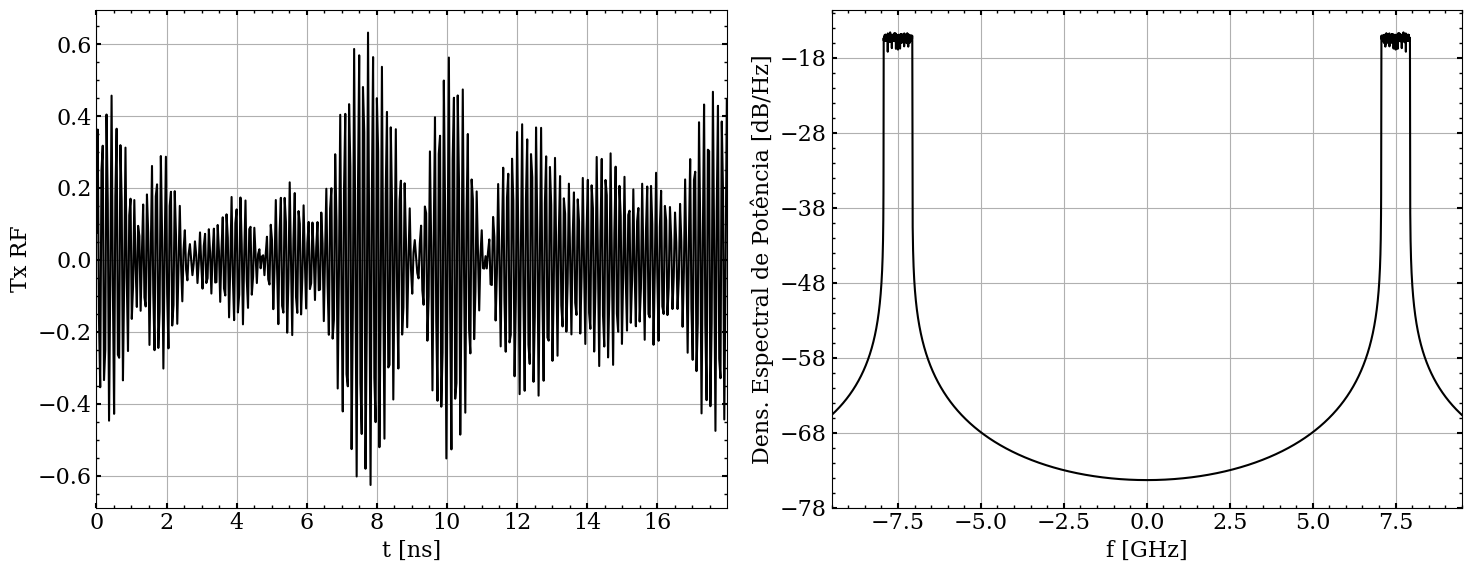

In [9]:

indx = np.arange(0, 500)

fig, axs = plt.subplots(1, 2, figsize = (15, 6))

axs[0].plot(t[indx]*1e9, sigTx_RF[indx], "k")
axs[1].psd(sigTx_RF, Fs = Fs/1e9, NFFT = 16*1024, sides = 'twosided', color = "k")

axs[0].set_xlim(0, t[indx][-1]*1e9)
axs[0].set_xlabel("t [ns]")
axs[0].set_ylabel("Tx RF")
axs[0].grid()
axs[0].minorticks_on()
axs[0].tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs[0].tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")

axs[1].set_xlabel("f [GHz]")
axs[1].set_ylabel("Dens. Espectral de Potência [dB/Hz]")
axs[1].set_xlim(-paramRF.fc_e/1e9 - 2, paramRF.fc_e/1e9 + 2)
axs[1].grid(True)
axs[1].minorticks_on()
axs[1].tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs[1].tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")

plt.tight_layout()
plt.show()

#### 2.2 Sinal óptico

In [10]:
Ai     = np.sqrt(dBm2W(paramMZM.Pin_OF))*np.ones(sigTx_RF.size)
sigTxo = mzm(Ai, sigTx_RF, paramMZM)

numtaps = 4096
hopt_tx = firwin(numtaps, paramRF.fc_e + 2*Rs, fs = Fs)
sigTxo = np.sqrt(signal_power(sigTxo))*pnorm(firFilter(hopt_tx, sigTxo))

sigRxo = linearFiberChannel(sigTxo, paramChannel)

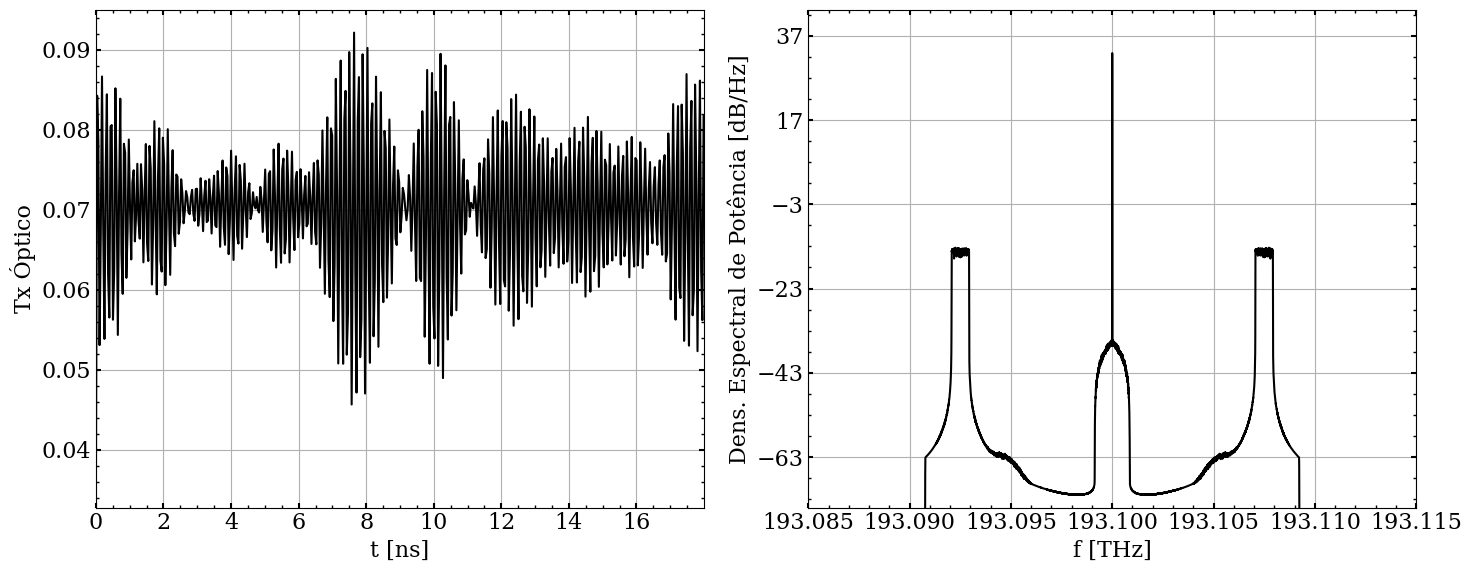

In [11]:
indx = np.arange(0, 500)
fig, axs = plt.subplots(1, 2, figsize = (15, 6))

axs[0].plot(t[indx]*1e9, sigTxo[indx], "k")
axs[1].psd(np.abs(sigTxo), Fs = Fs/1e12, Fc = paramChannel.Fc/1e12, NFFT = 16*1024, sides = 'twosided', color = "k")

axs[0].set_xlim(0, t[indx][-1]*1e9)
axs[0].set_xlabel("t [ns]")
axs[0].set_ylabel("Tx Óptico")
axs[0].grid()
axs[0].minorticks_on()
axs[0].tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs[0].tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")

axs[1].set_xlabel("f [THz]")
axs[1].set_ylabel("Dens. Espectral de Potência [dB/Hz]")
axs[1].set_xlim(-0.015 + paramChannel.Fc/1e12, 0.015 + paramChannel.Fc/1e12)
axs[1].set_ylim(-75)
axs[1].grid(True)
axs[1].minorticks_on()
axs[1].tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs[1].tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")

plt.tight_layout()
plt.show()

#### 2.3 Sinal elétrico (fotocorrente)

In [12]:
I_Rx = photodiode(sigRxo, paramPD)
I_Rx -= I_Rx.mean()

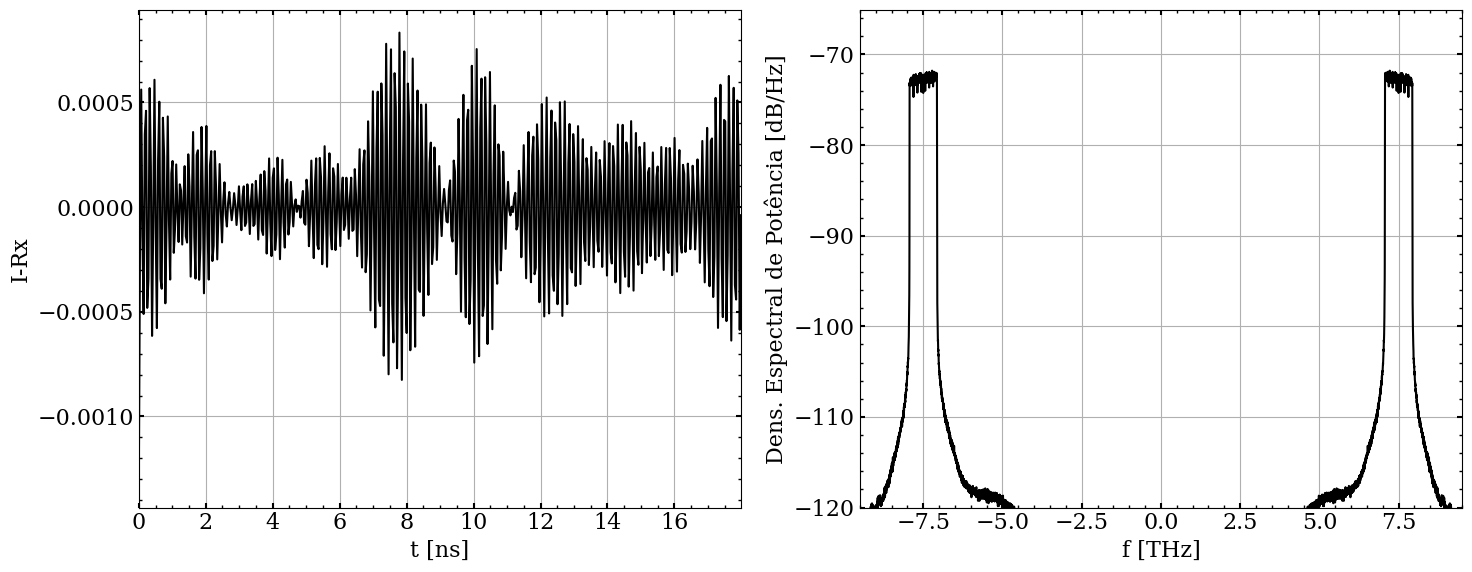

In [13]:

indx = np.arange(0, 500)
fig, axs = plt.subplots(1, 2, figsize = (15, 6))

axs[0].plot(t[indx]*1e9, I_Rx[indx], "k")
axs[1].psd(I_Rx, Fs = Fs/1e9, NFFT = 16*1024, sides = 'twosided', color = "k")

axs[0].set_xlim(0, t[indx][-1]*1e9)
axs[0].set_xlabel("t [ns]")
axs[0].set_ylabel("I-Rx")
axs[0].grid()
axs[0].minorticks_on()
axs[0].tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs[0].tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")

axs[1].set_xlabel("f [THz]")
axs[1].set_ylabel("Dens. Espectral de Potência [dB/Hz]")
axs[1].set_xlim(- paramRF.fc_e/1e9 - 2,  paramRF.fc_e/1e9 + 2)
axs[1].set_ylim(-120)
axs[1].grid(True)
axs[1].set_yticks(np.arange(-120, -60, 10))
axs[1].minorticks_on()
axs[1].tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs[1].tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")

plt.tight_layout()
plt.show()

#### 2.4 Sinal elétrico pós-FPF

In [14]:
# Filtro passa-faixas
numtaps = 4096
f1 = paramRF.fc_e - 2*Rs
f2 = paramRF.fc_e + 2*Rs
hbp_RF = firwin(numtaps, (f1, f2), pass_zero = 'bandpass', fs = Fs)

I_RF = firFilter(hbp_RF, I_Rx)

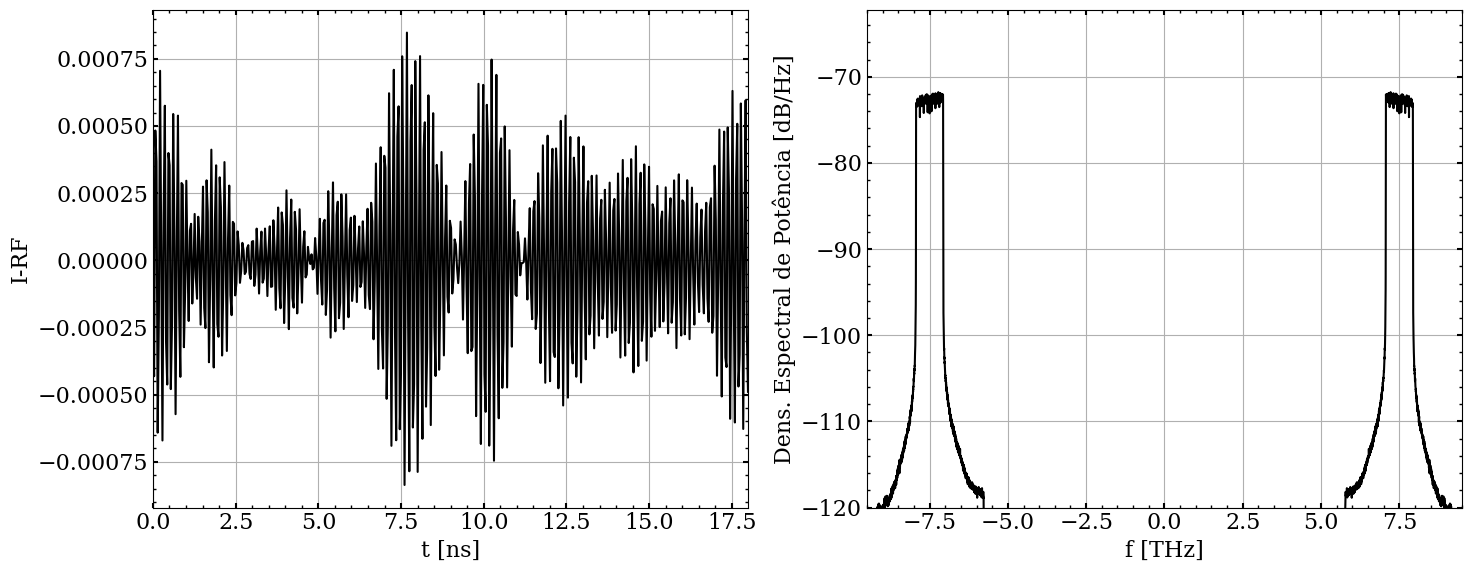

In [15]:

indx = np.arange(0, 500)
fig, axs = plt.subplots(1, 2, figsize = (15, 6))

axs[0].plot(t[indx]*1e9, I_RF[indx], "k")
axs[1].psd(I_RF, Fs = Fs/1e9, NFFT = 16*1024, sides = 'twosided', color = "k")

axs[0].set_xlim(0, t[indx][-1]*1e9)
axs[0].set_xlabel("t [ns]")
axs[0].set_ylabel("I-RF")
axs[0].grid()
axs[0].minorticks_on()
axs[0].tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs[0].tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")

axs[1].set_xlabel("f [THz]")
axs[1].set_ylabel("Dens. Espectral de Potência [dB/Hz]")
axs[1].set_xlim(- paramRF.fc_e/1e9 - 2,  paramRF.fc_e/1e9 + 2)
axs[1].set_ylim(-120)
axs[1].grid(True)
axs[1].set_yticks(np.arange(-120, -60, 10))
axs[1].minorticks_on()
axs[1].tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs[1].tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")

plt.tight_layout()
plt.show()

#### 2.5 Sinal elétrico pós-PA

In [17]:
sigRx = hilbert(I_RF)*np.exp(-1j*2*pi*paramRF.fc_e*t)

alpha = 1 # dB
theta = 5 # degrees

IQ_imb = 1 # 10**(alpha / 10) * np.exp(1j*theta * pi/180)
sigRx = sigRx.real + 1j*sigRx.imag * IQ_imb

gain_pre_PA = 10**( np.log10(dBm2W(paramRF.Pin_PA)/signal_power(sigRx))/2)
sigRx *= gain_pre_PA

sigRx = power_amplifier(sigRx)

sigRx_PA = sigRx.copy()
sigRx_PA = pnorm(sigRx_PA)

numtaps = 4096
hlp = firwin(numtaps, Rs/1.75, fs = Fs)
sigRx = firFilter(hlp, sigRx)

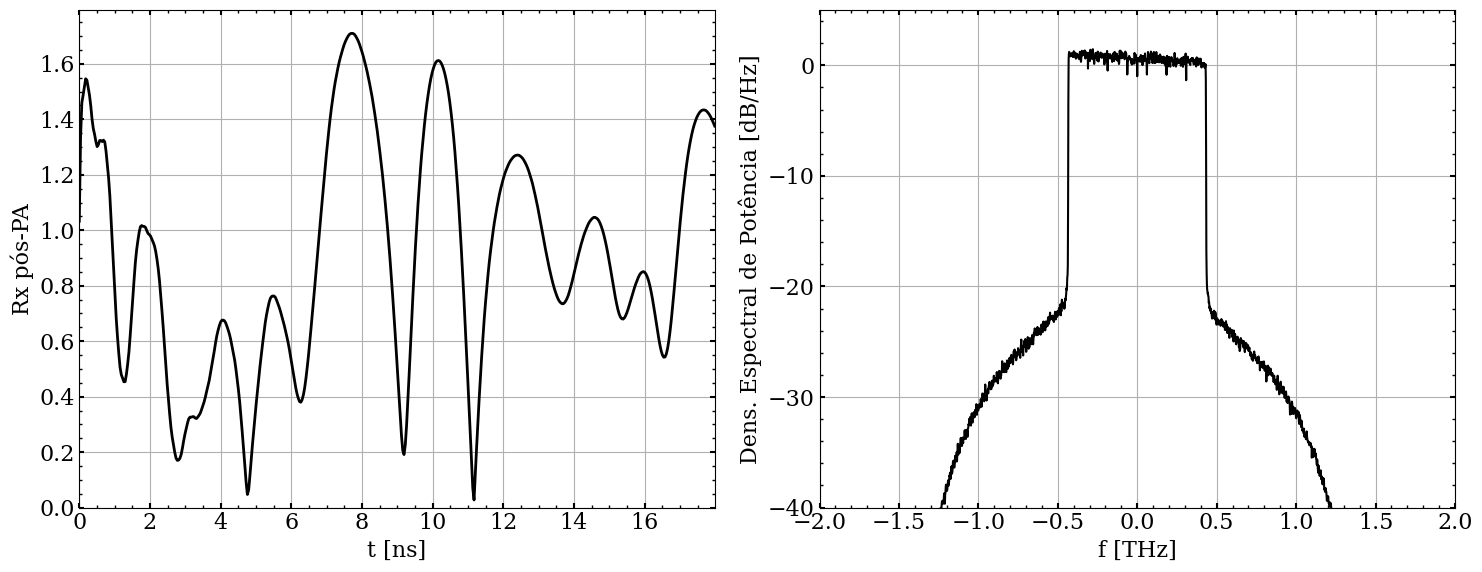

In [18]:

indx = np.arange(0, 500)
fig, axs = plt.subplots(1, 2, figsize = (15, 6))

axs[0].plot(t[indx]*1e9, np.abs(sigRx_PA[indx]), "k", lw = 2)
axs[1].psd(sigRx_PA, Fs = Fs/1e9, NFFT = 16*1024, sides = 'twosided', color = "k")

axs[0].set_xlim(0, t[indx][-1]*1e9)
axs[0].set_xlabel("t [ns]")
axs[0].set_ylabel("Rx pós-PA")
axs[0].set_ylim(0)
axs[0].grid()
axs[0].minorticks_on()
axs[0].tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs[0].tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")

axs[1].set_xlabel("f [THz]")
axs[1].set_ylabel("Dens. Espectral de Potência [dB/Hz]")
axs[1].set_xlim(-2, 2)
axs[1].set_ylim(-40, 5)
axs[1].grid(True)
axs[1].set_yticks(np.arange(-40, 5, 10))
axs[1].minorticks_on()
axs[1].tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs[1].tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")

plt.tight_layout()
plt.show()

In [19]:
delay = finddelay(sigRx, sigTx)
sigRx = np.roll(sigRx, -delay)

rot = np.mean(sigTx/sigRx)
sigRx = rot/np.abs(rot)*sigRx

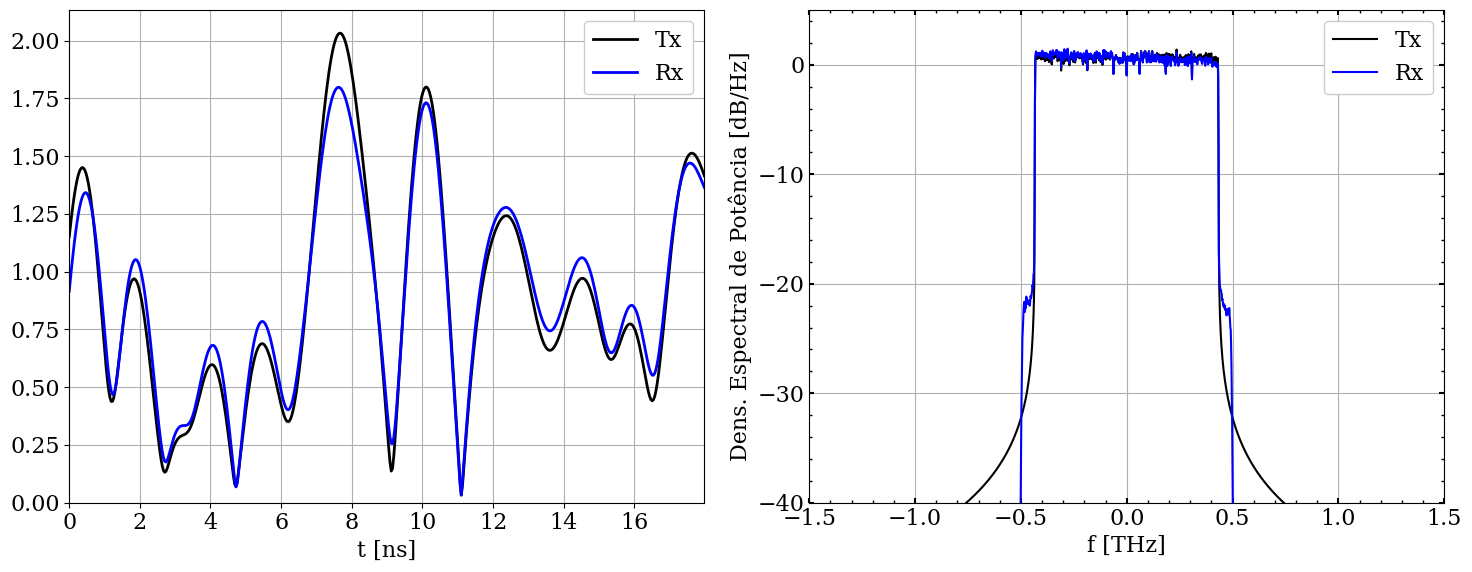

In [20]:

indx = np.arange(0, 500)
fig, axs = plt.subplots(1, 2, figsize = (15, 6))

axs[0].plot(t[indx]*1e9, np.abs(pnorm(sigTx))[indx], label = "Tx", lw = 2, color = "k")
axs[0].plot(t[indx]*1e9, np.abs(pnorm(sigRx))[indx], label = "Rx", lw = 2, color = "b")

axs[1].psd(pnorm(sigTx), Fs = Fs/1e9, NFFT = 16*1024, sides = 'twosided', label = "Tx", color = "k")
axs[1].psd(pnorm(sigRx), Fs = Fs/1e9, NFFT = 16*1024, sides = 'twosided', label = "Rx", color = "b")

axs[0].set_xlim(0, t[indx][-1]*1e9)
axs[0].set_xlabel("t [ns]")
axs[0].set_ylim(0)
axs[0].grid()
axs[0].legend(framealpha = 1)

axs[1].set_xlabel("f [THz]")
axs[1].set_ylabel("Dens. Espectral de Potência [dB/Hz]")
axs[1].set_xlim(-1.5, 1.5)
axs[1].set_ylim(-40, 5)
axs[1].grid(True)
axs[1].set_yticks(np.arange(-40, 5, 10))
axs[1].minorticks_on()
axs[1].tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs[1].tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")
axs[1].legend(framealpha = 1)

plt.tight_layout()
plt.show()

#### 2.6 Performance

In [21]:
# Parâmetros da decimação
paramDec = parameters()
paramDec.SpS_in  = SpS
paramDec.SpS_out = 1

symbRx_OFDM = decimate(sigRx, paramDec).ravel()
symbRx = demodulateOFDM(symbRx_OFDM, paramOFDM)

BER = 0.00388 
SNR = 21.206 dB


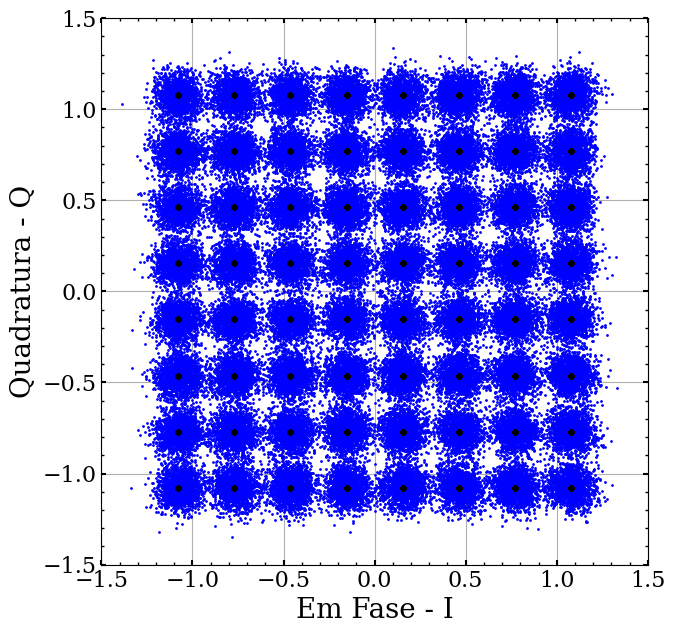

In [22]:
discard = Ni
index = np.arange(discard, symbTx.size - discard)
BER, SER, SNR = fastBERcalc(symbRx[index], symbTx[index], modOrder, modType)

EVM = 10*np.log10(calcEVM(symbRx, modOrder, modType))

print(f"BER = {BER[0]:.5f} \nSNR = {SNR[0]:.3f} dB")

# Normalização para o plot
symbTx = pnorm(symbTx)
symbRx = pnorm(symbRx)

fig, axs = plt.subplots(figsize = (7, 7))
axs.plot(symbRx.real, symbRx.imag, "o", color = "b", ms = 1, label = "SymbRx")
axs.plot(symbTx.real, symbTx.imag, "o", color = "k", ms = 3, label = "SymbTx")
axs.set_ylabel("Quadratura - Q", fontsize = 20)
axs.set_xlabel("Em Fase - I", fontsize = 20)
plt.axis("square")

axs.set_xlim(-1.5, 1.5)
axs.set_ylim(-1.5, 1.5)
axs.minorticks_on()
axs.tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs.tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")
plt.grid()

plt.tight_layout()
plt.savefig("constelacao_noDPD.png")

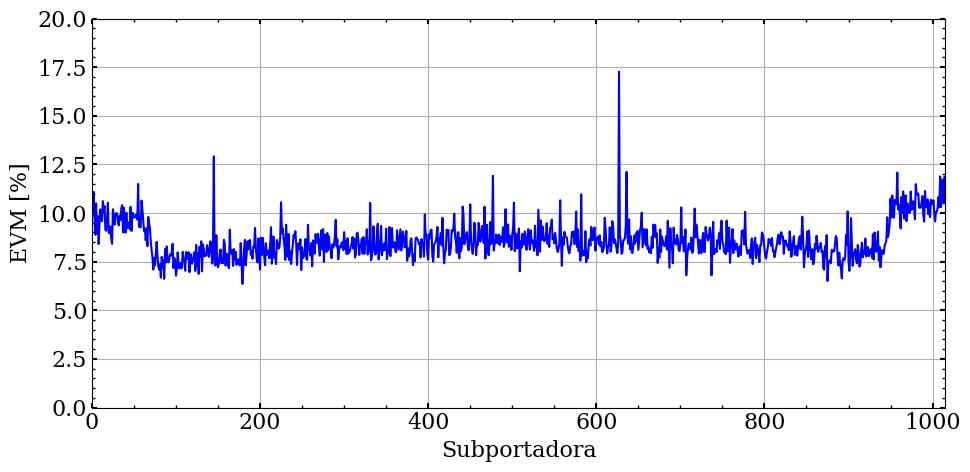

In [23]:
_, SNR_per_carrier, EVM_per_carrier = calc_per_carrier(symbTx, symbRx, Ni, numOFDMframes)

fig, axs = plt.subplots(figsize = (10, 5))
axs.plot(EVM_per_carrier, color = "b")
axs.set_xlim(0, Ni)
axs.set_ylim(0, 20)
axs.set_ylabel("EVM [%]")
axs.set_xlabel("Subportadora")
axs.grid()
axs.minorticks_on()
axs.tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs.tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")
plt.tight_layout()

### 3 Identificação do canal

In [24]:
SpS_mp = 4

paramDec = parameters()
paramDec.SpS_in = SpS
paramDec.SpS_out = SpS_mp

hlp = firwin(numtaps, SpS_mp*Rs/2, fs = Fs)

sigRef = decimate(pnorm(firFilter(hlp, sigTx)), paramDec).ravel()
sigIn  = decimate(pnorm(firFilter(hlp, sigRx_PA)), paramDec).ravel()

In [25]:
delay = finddelay(sigIn, sigRef)
sigIn = np.roll(sigIn, -delay)

rot = np.mean(sigRef/sigIn)
sigIn = rot/np.abs(rot)*sigIn

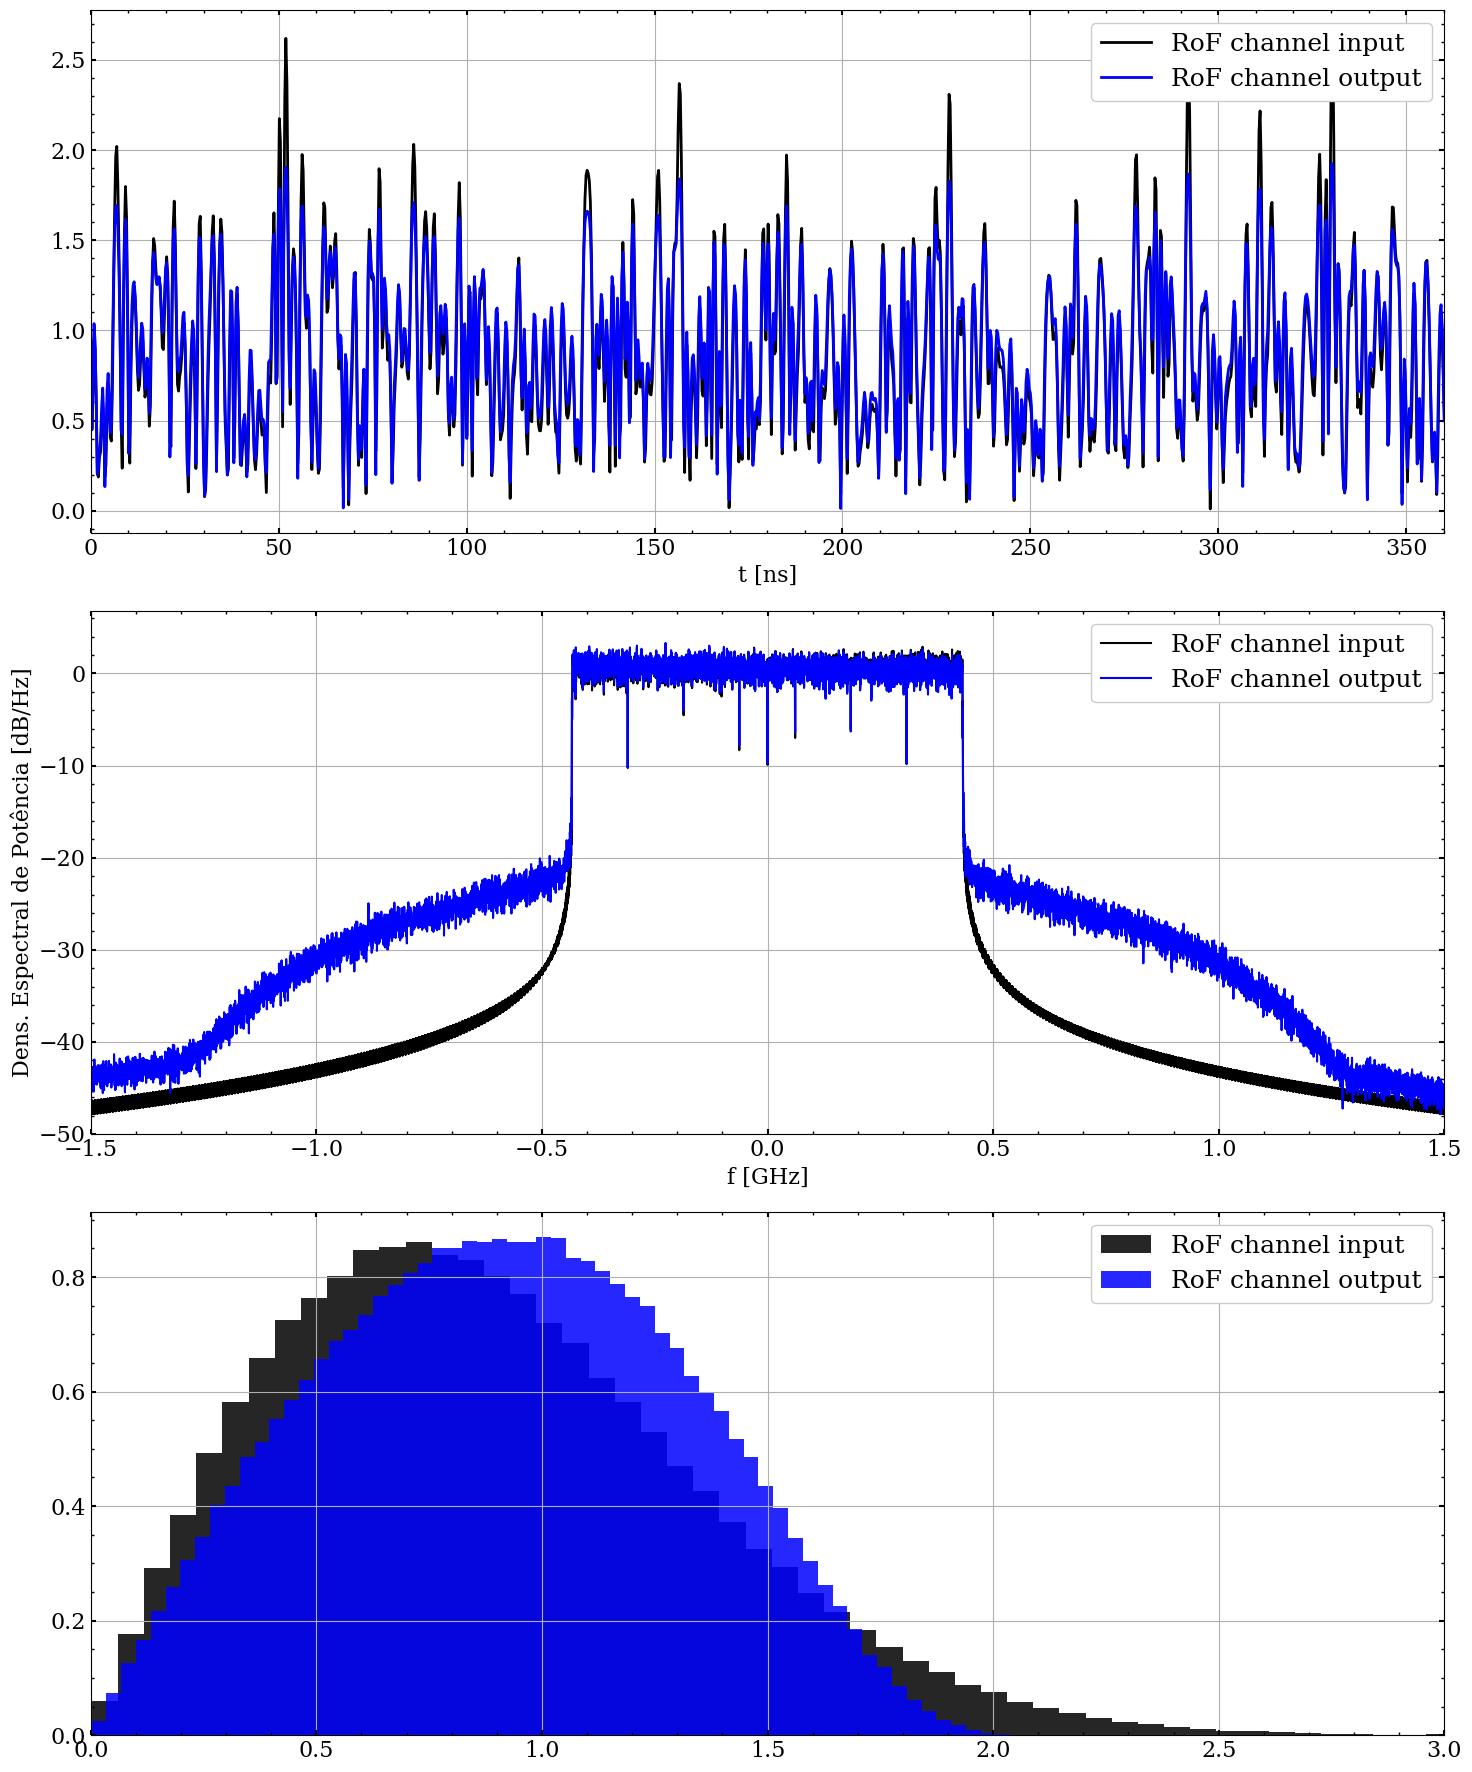

In [26]:
indx = np.arange(0, int(10000*SpS_mp/SpS))
fig, axs = plt.subplots(3, 1, figsize = (15, 18))
t = np.arange(0, sigRef.size)*(1/Fs)*(SpS/SpS_mp)

axs[0].plot(t[indx]*1e9, np.abs(sigRef[indx]), "k", lw = 2, label = "RoF channel input")
axs[0].plot(t[indx]*1e9, np.abs(sigIn[indx]), "b", lw = 2, label = "RoF channel output")

axs[1].psd(sigRef, Fs = (SpS_mp/SpS)*Fs/1e9, NFFT = 16*1024, sides = 'twosided', color = "k", label = "RoF channel input")
axs[1].psd(sigIn, Fs = (SpS_mp/SpS)*Fs/1e9, NFFT = 16*1024, sides = 'twosided', color = "b", label = "RoF channel output")

axs[0].set_xlim(0, np.max(t[indx]*1e9))
axs[0].set_xlabel("t [ns]")
axs[0].grid()
axs[0].minorticks_on()
axs[0].tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs[0].tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")
axs[0].legend(framealpha = 1, fontsize = 18, loc = "upper right")

axs[1].set_xlabel("f [GHz]")
axs[1].set_ylabel("Dens. Espectral de Potência [dB/Hz]")
axs[1].set_xlim(-1.5, 1.5)
axs[1].set_ylim(-50)
axs[1].grid(True)
axs[1].minorticks_on()
axs[1].tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs[1].tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")
axs[1].legend(framealpha = 1, fontsize = 18, loc = "upper right")

axs[2].hist(np.abs(sigRef), color = "k", density = True, bins = 64, label = 'RoF channel input', alpha = 0.85)
axs[2].hist(np.abs(sigIn), color = "b", density = True, bins = 64, label = 'RoF channel output', alpha = 0.85)
axs[2].set_xlim(0, 3)
axs[2].grid()
axs[2].minorticks_on()
axs[2].tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs[2].tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")
axs[2].legend(framealpha = 1, fontsize = 18, loc = "upper right")

plt.tight_layout()
plt.show()

In [27]:
P1 = 3
M1 = 2

P2 = 3
M2 = 2

N = 50_000

a_1, a_2   = LS_CMP_solver(sigRef[0:N], sigIn[0:N], P1, P2, M1, M2)

In [28]:
sig_mp = CMP_filter(sigRef, a_1, a_2)
sig_mp = pnorm(sig_mp)

MSE = -31.496 dB


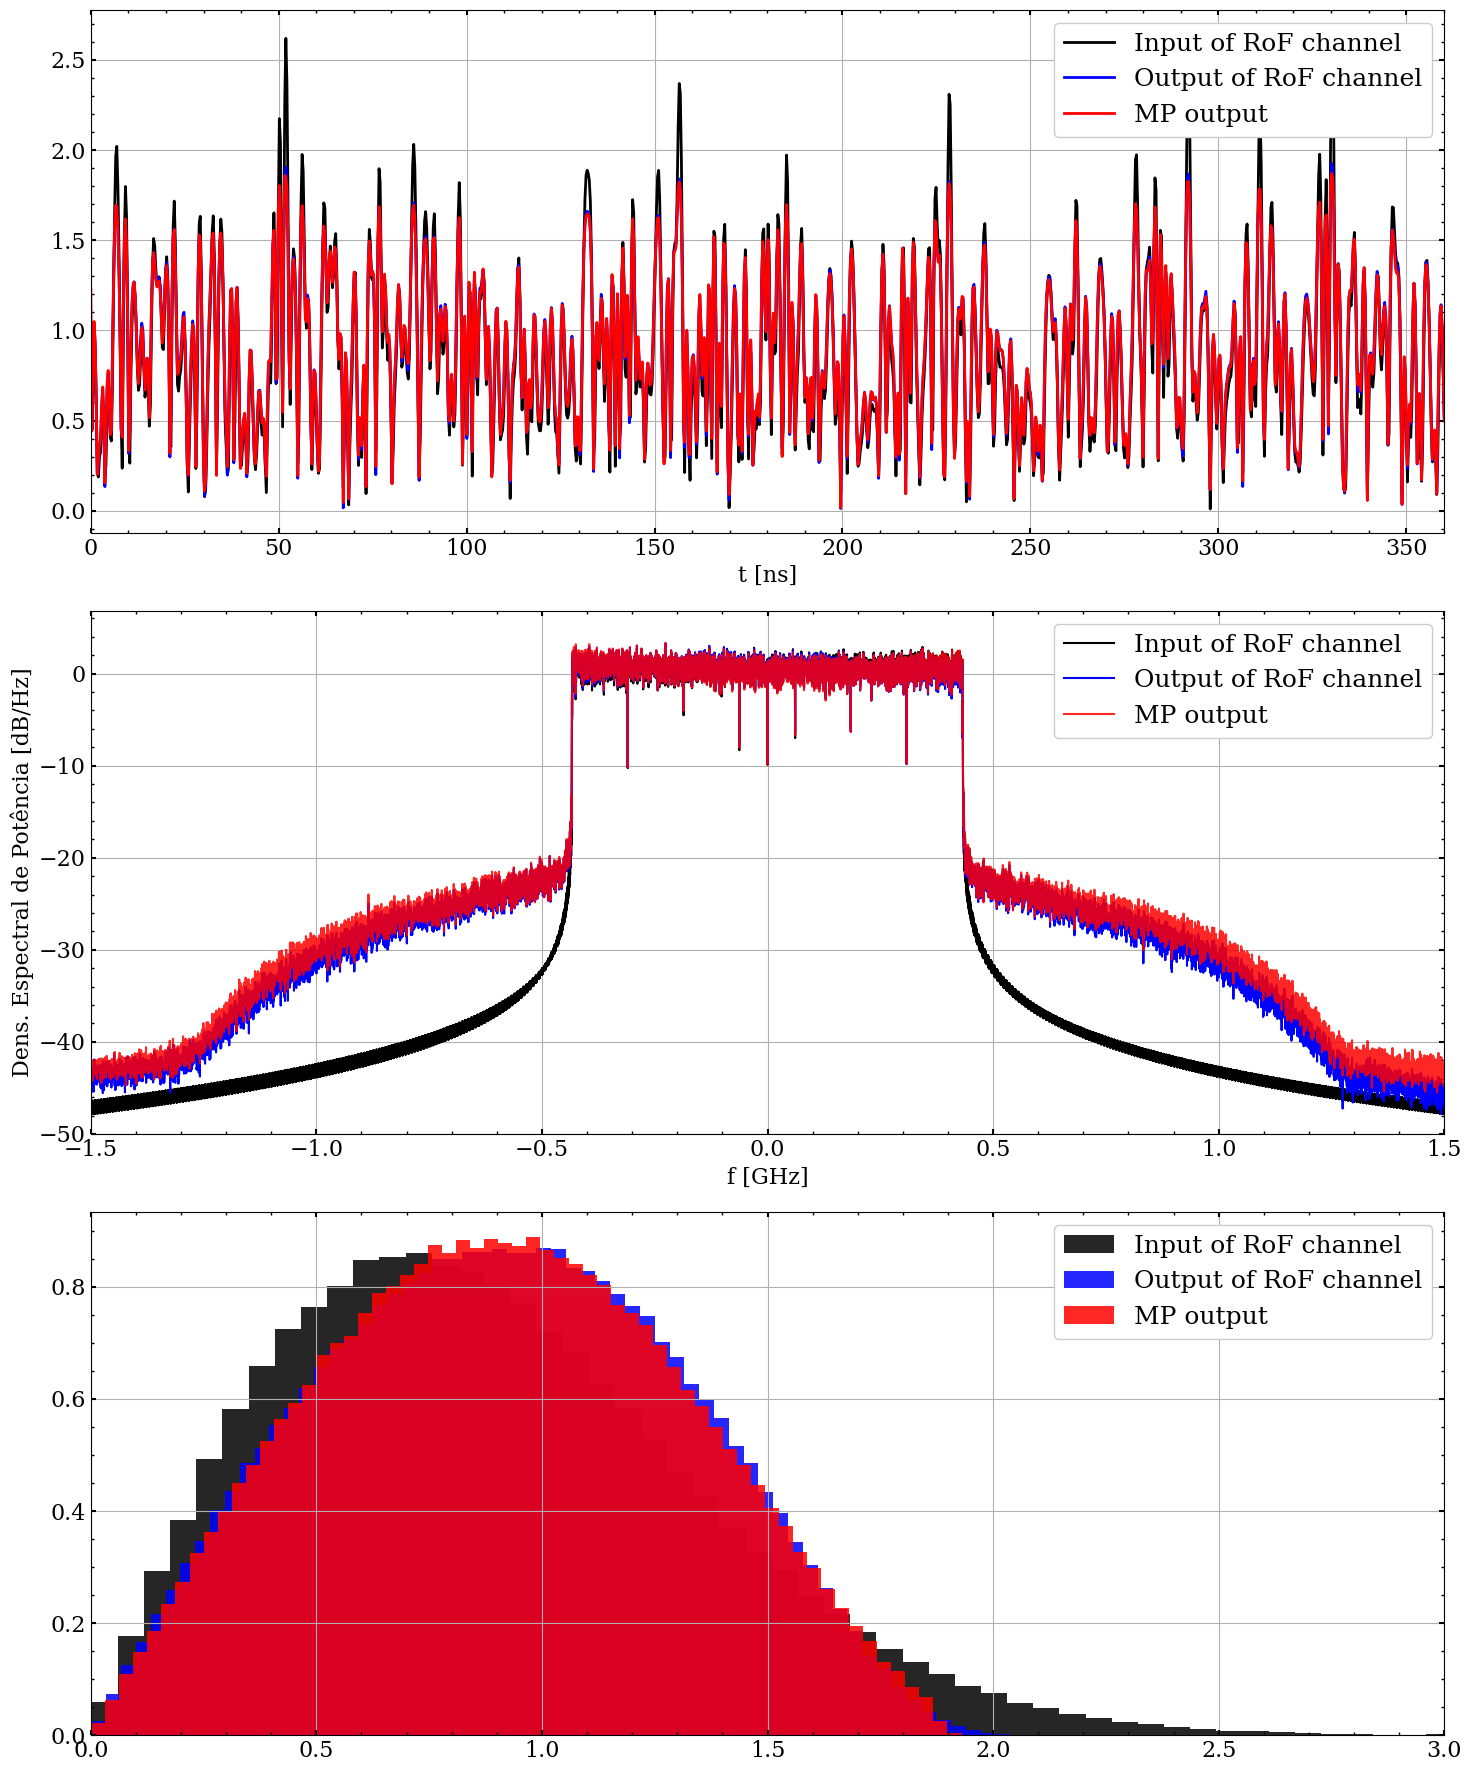

In [29]:
indx = np.arange(0, int(10000*SpS_mp/SpS))
fig, axs = plt.subplots(3, 1, figsize = (15, 18))
t = np.arange(0, sigRef.size)*(1/Fs)*(SpS/SpS_mp)

print(f"MSE = {10*np.log10(np.mean(np.abs(sig_mp - sigIn)**2)):.3f} dB")

axs[0].plot(t[indx]*1e9, np.abs(sigRef[indx]), "k", lw = 2, label = "Input of RoF channel")
axs[0].plot(t[indx]*1e9, np.abs(sigIn[indx]),  "b", lw = 2, label = "Output of RoF channel")
axs[0].plot(t[indx]*1e9, np.abs(sig_mp[indx]), "r", lw = 2, label = "MP output")

axs[0].set_xlim(0, np.max(t[indx])*1e9)
axs[0].legend(framealpha = 1, fontsize = 18, loc = "upper right")
axs[0].set_xlabel("t [ns]")
axs[0].grid()
axs[0].minorticks_on()
axs[0].tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs[0].tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")

axs[1].psd(sigRef, Fs = (SpS_mp/SpS)*Fs/1e9, NFFT = 16*1024, sides = 'twosided', color = "k", label = "Input of RoF channel")
axs[1].psd(sigIn, Fs = (SpS_mp/SpS)*Fs/1e9, NFFT = 16*1024, sides = 'twosided', color = "b", label = "Output of RoF channel")
axs[1].psd(sig_mp, Fs = (SpS_mp/SpS)*Fs/1e9, NFFT = 16*1024, sides = 'twosided', color = "r", label = "MP output", alpha = 0.85)
axs[1].set_xlabel("f [GHz]")
axs[1].set_ylabel("Dens. Espectral de Potência [dB/Hz]")
axs[1].set_xlim(-1.5, 1.5)
axs[1].set_ylim(-50)
axs[1].grid(True)
axs[1].minorticks_on()
axs[1].tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs[1].tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")
axs[1].legend(framealpha = 1, fontsize = 18, loc = "upper right")

axs[2].hist(np.abs(sigRef), density = True, bins = 64, color = "k", label = 'Input of RoF channel', alpha = 0.85)
axs[2].hist(np.abs(sigIn), density = True, bins = 64, color = "b", label = 'Output of RoF channel', alpha = 0.85)
axs[2].hist(np.abs(sig_mp), density = True, bins = 64, color = "r", label = 'MP output', alpha = 0.85)
axs[2].set_xlim(0, 3)
axs[2].grid()
axs[2].minorticks_on()
axs[2].tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs[2].tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")
axs[2].legend(framealpha = 1, fontsize = 18, loc = "upper right")

plt.tight_layout()
plt.show()

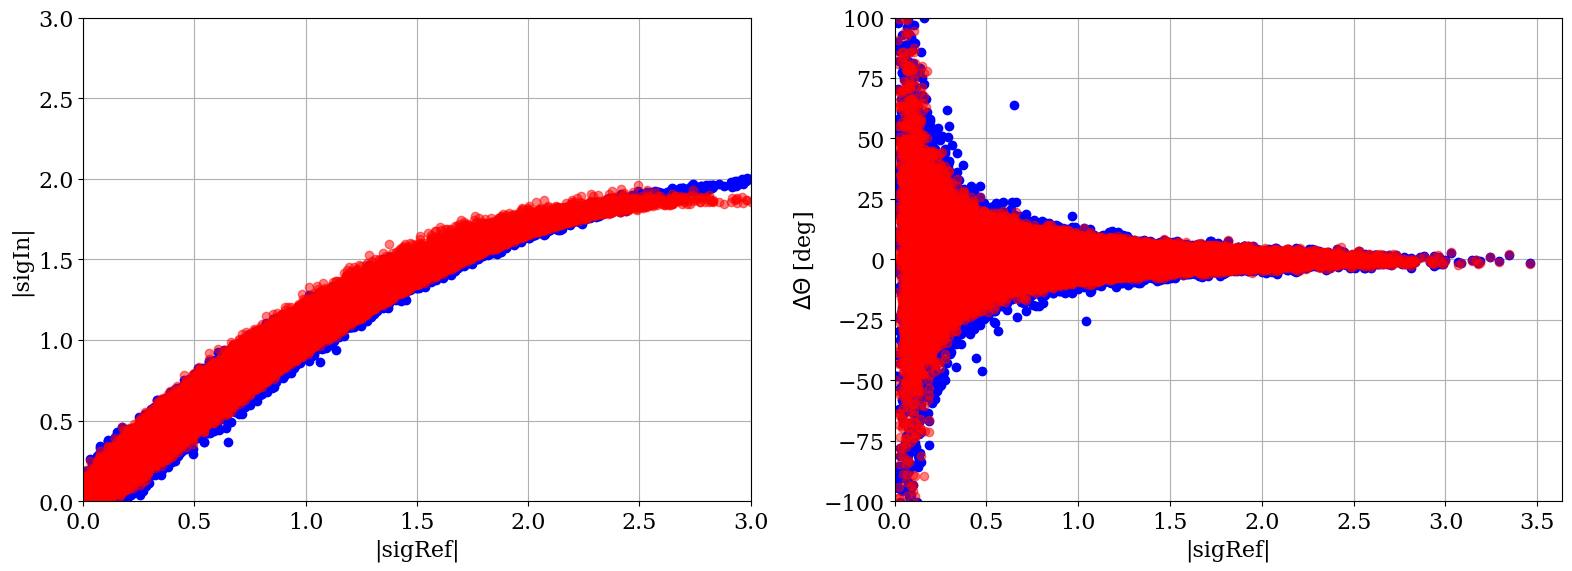

In [30]:
fig, axs = plt.subplots(1, 2, figsize = (16, 6))

n_pts = 100_000

axs[0].plot(np.abs(sigRef[0:n_pts]), np.abs(sigIn[0:n_pts]), "o", color = "b")
axs[0].plot(np.abs(sigRef[0:n_pts]), np.abs(sig_mp[0:n_pts]), "o", color = "r", alpha = 0.5)
axs[0].set_xlim(0,3)
axs[0].set_ylim(0,3)
axs[0].set_xlabel("|sigRef|")
axs[0].set_ylabel("|sigIn|")
axs[0].grid()

axs[1].plot(np.abs(sigRef[0:n_pts]), (np.angle(sigIn) - np.angle(sigRef))[0:n_pts]*180/pi, "o", color = "b")
axs[1].plot(np.abs(sigRef[0:n_pts]), (np.angle(sig_mp) - np.angle(sigRef))[0:n_pts]*180/pi, "o", color = "r", alpha = 0.5)
axs[1].set_xlim(0)
axs[1].set_ylim(-100, 100)
axs[1].set_xlabel("|sigRef|")
axs[1].set_ylabel("$\Delta \Theta$ [deg]")
axs[1].grid()

plt.tight_layout()

### 4 - Arquitetura de Aprendizado Indireto (ILA)

In [31]:
N = 20_000

w_1, w_2   = LS_CMP_solver(sigIn[0:N], sigRef[0:N], P1, P2, M1, M2)
sig_mp = CMP_filter(sigIn, w_1, w_2)
sig_mp = pnorm(sig_mp)

MSE = -33.369 dB


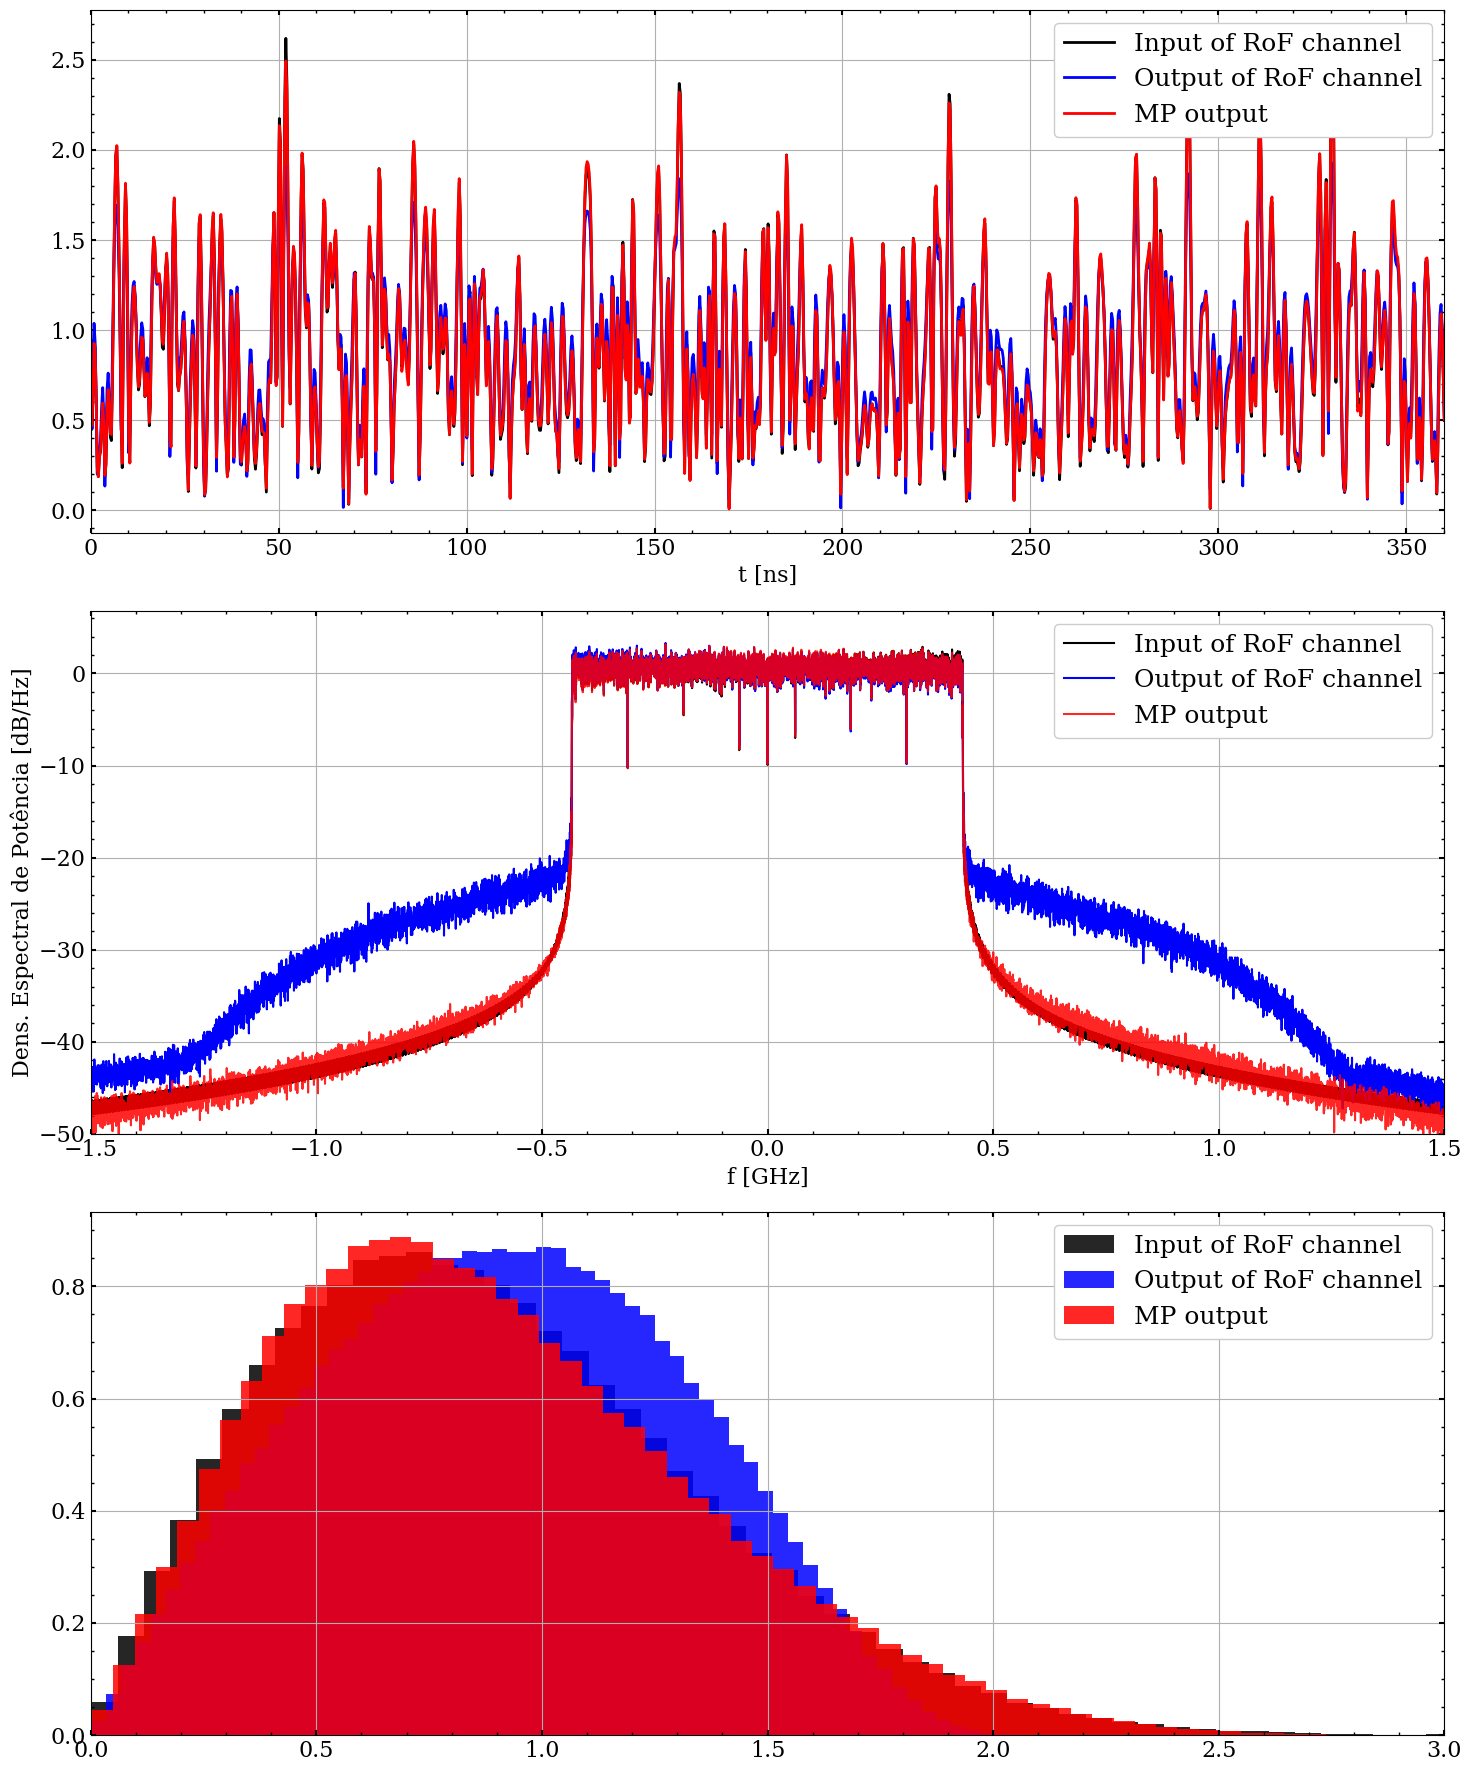

In [32]:
print(f"MSE = {10*np.log10(np.mean(np.abs(sig_mp - sigRef)**2)):.3f} dB")

indx = np.arange(0, int(10000*SpS_mp/SpS))
fig, axs = plt.subplots(3, 1, figsize = (15, 18))
t = np.arange(0, sigRef.size)*(1/Fs)*(SpS/SpS_mp)

axs[0].plot(t[indx]*1e9, np.abs(sigRef[indx]), "k", lw = 2, label = "Input of RoF channel")
axs[0].plot(t[indx]*1e9, np.abs(sigIn[indx]),  "b", lw = 2, label = "Output of RoF channel")
axs[0].plot(t[indx]*1e9, np.abs(sig_mp[indx]), "r", lw = 2, label = "MP output")

axs[0].set_xlim(0, np.max(t[indx])*1e9)
axs[0].legend(framealpha = 1, fontsize = 18, loc = "upper right")
axs[0].set_xlabel("t [ns]")
axs[0].grid()
axs[0].minorticks_on()
axs[0].tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs[0].tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")

axs[1].psd(sigRef, Fs = (SpS_mp/SpS)*Fs/1e9, NFFT = 16*1024, sides = 'twosided', color = "k", label = "Input of RoF channel")
axs[1].psd(sigIn, Fs = (SpS_mp/SpS)*Fs/1e9, NFFT = 16*1024, sides = 'twosided', color = "b", label = "Output of RoF channel")
axs[1].psd(sig_mp, Fs = (SpS_mp/SpS)*Fs/1e9, NFFT = 16*1024, sides = 'twosided', color = "r", label = "MP output", alpha = 0.85)
axs[1].set_xlabel("f [GHz]")
axs[1].set_ylabel("Dens. Espectral de Potência [dB/Hz]")
axs[1].set_xlim(-1.5, 1.5)
axs[1].set_ylim(-50)
axs[1].grid(True)
axs[1].minorticks_on()
axs[1].tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs[1].tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")
axs[1].legend(framealpha = 1, fontsize = 18, loc = "upper right")

axs[2].hist(np.abs(sigRef), density = True, bins = 64, color = "k", label = 'Input of RoF channel', alpha = 0.85)
axs[2].hist(np.abs(sigIn), density = True, bins = 64, color = "b", label = 'Output of RoF channel', alpha = 0.85)
axs[2].hist(np.abs(sig_mp), density = True, bins = 64, color = "r", label = 'MP output', alpha = 0.85)
axs[2].set_xlim(0, 3)
axs[2].grid()
axs[2].minorticks_on()
axs[2].tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs[2].tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")
axs[2].legend(framealpha = 1, fontsize = 18, loc = "upper right")

plt.tight_layout()
plt.show()

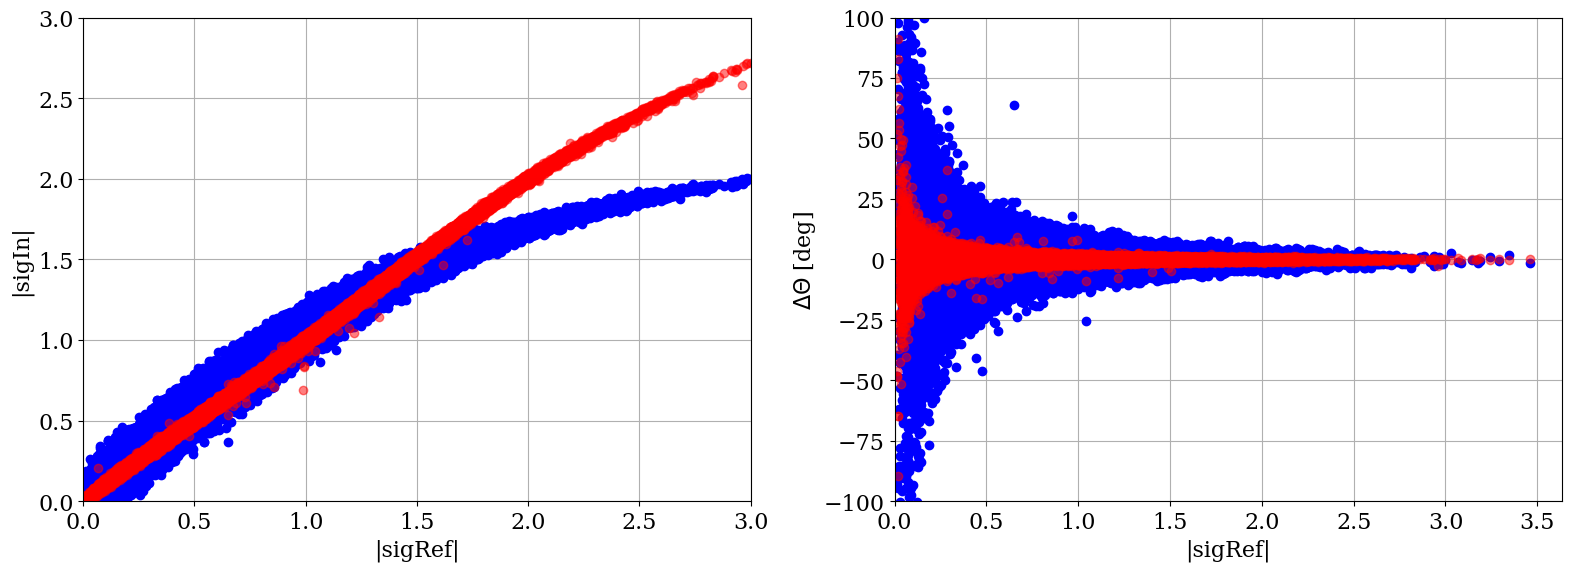

In [33]:
fig, axs = plt.subplots(1, 2, figsize = (16, 6))

n_pts = 100_000

axs[0].plot(np.abs(sigRef[0:n_pts]), np.abs(sigIn[0:n_pts]), "o", color = "b")
axs[0].plot(np.abs(sigRef[0:n_pts]), np.abs(sig_mp[0:n_pts]), "o", color = "r", alpha = 0.5)
axs[0].set_xlim(0,3)
axs[0].set_ylim(0,3)
axs[0].set_xlabel("|sigRef|")
axs[0].set_ylabel("|sigIn|")
axs[0].grid()

axs[1].plot(np.abs(sigRef[0:n_pts]), (np.angle(sigIn) - np.angle(sigRef))[0:n_pts]*180/pi, "o", color = "b")
axs[1].plot(np.abs(sigRef[0:n_pts]), (np.angle(sig_mp) - np.angle(sigRef))[0:n_pts]*180/pi, "o", color = "r", alpha = 0.5)
axs[1].set_xlim(0)
axs[1].set_ylim(-100, 100)
axs[1].set_xlabel("|sigRef|")
axs[1].set_ylabel("$\Delta \Theta$ [deg]")
axs[1].grid()

plt.tight_layout()

### 6 - DPD Test

In [35]:
# Parâmetros OFDM
paramOFDM = parameters()
paramOFDM.Nfft = 1024                 # Tam. da FFT
paramOFDM.G    = 32                   # Tam. do prefixo cíclico
paramOFDM.hermitSymmetry = False
paramOFDM.SpS = SpS_mp

if paramOFDM.hermitSymmetry:
    Ns = paramOFDM.Nfft//2 - 1
    paramOFDM.pilotCarriers = np.linspace(0, Ns - 1, 8, dtype = np.int64)
    paramOFDM.nullCarriers  = np.array([], dtype = np.int64)
else:
    Ns = paramOFDM.Nfft
    paramOFDM.pilotCarriers = np.linspace(0, Ns - 1, 8, dtype = np.int64)
    paramOFDM.nullCarriers  = np.array([paramOFDM.Nfft//2], dtype = np.int64)

# Núm. de subportadoras de informação
Np = paramOFDM.pilotCarriers.size
Nz = paramOFDM.nullCarriers.size
Ni = Ns - Np - Nz

Rs = Rb / ( Ni/(paramOFDM.Nfft + paramOFDM.G) * np.log2(modOrder) )    # Taxa de transmissão de símbolos
Fs = Rs * SpS                                                          # Taxa de amostragem

# Geração dos bits e dos símbolos QAM
numOFDMframes = 100
np.random.seed(3)
bits = np.random.randint(2, size = (numOFDMframes*Ni, int(np.log2(modOrder))))

symbTx = modulateGray(bits, modOrder, modType)
symbTx = pnorm(symbTx)

pilotSymb = 0.25*(max(symbTx.real) + 1j*max(symbTx.imag))
paramOFDM.pilot = pilotSymb

In [36]:
sigTx = modulateOFDM(symbTx, paramOFDM)
sigTx = pnorm(sigTx)

sigTx_DPD_ILA = CMP_filter(sigTx, w_1, w_2)
gain_ILA = np.sqrt(signal_power(sigTx_DPD_ILA))

In [37]:
numtaps = 4096
h_dpd = firwin(numtaps, 2*Rs, fs = Fs)

# ILA
sigTx_DPD_ILA = upsample(sigTx_DPD_ILA.ravel(), SpS//SpS_mp).reshape(-1,) 
sigTx_DPD_ILA = firFilter(h_dpd, sigTx_DPD_ILA)
sigTx_DPD_ILA = pnorm(sigTx_DPD_ILA)

t = np.arange(0, sigTx_DPD_ILA.size)*1/Fs
t_CP   = SpS * paramOFDM.G * (1/Fs)
t_symb = SpS * (paramOFDM.Nfft + paramOFDM.G) * (1/Fs)

#### 6.1 Sinal RF

In [38]:
sigTx_RF_ILA = np.real( sigTx_DPD_ILA * gain_ILA * np.exp(1j*2*pi*paramRF.fc_e*t) )
sigTx_RF_ILA *= gain_pre_MZM
sigTx_RF_ILA = np.clip(sigTx_RF_ILA, -paramMZM.Vpi/2, paramMZM.Vpi/2)

print(f"Power at MZM's input with ILA-DPD: {10*np.log10(1e3*signal_power(sigTx_RF_ILA)):.3f} dBm")

Power at MZM's input with ILA-DPD: 17.686 dBm


#### 6.2 Sinal óptico

In [39]:
Ai     = np.sqrt(dBm2W(paramMZM.Pin_OF))*np.ones(sigTx_RF_ILA.size)
sigTxo_ILA = mzm(Ai, sigTx_RF_ILA, paramMZM)

numtaps = 4096
hopt_tx = firwin(numtaps, paramRF.fc_e + 2*Rs, fs = Fs)
sigTxo_ILA = np.sqrt(signal_power(sigTxo_ILA))*pnorm(firFilter(hopt_tx, sigTxo_ILA))

sigRxo_ILA = linearFiberChannel(sigTxo_ILA, paramChannel)

print(f"P_Txo = {10*np.log10(signal_power(sigTxo_ILA)*1e3):.3f} dBm")
print(f"P_Rxo = {10*np.log10(signal_power(sigRxo_ILA)*1e3):.3f} dBm")

P_Txo = 6.990 dBm
P_Rxo = 1.990 dBm


#### 6.3 Sinal elétrico (fotocorrente)

In [40]:
I_Rx_ILA = photodiode(sigRxo_ILA, paramPD)
I_Rx_ILA -= I_Rx_ILA.mean()

#### 6.4 Sinal elétrico pós-FPF

In [41]:
# Filtro passa-faixas
numtaps = 4096
f1 = paramRF.fc_e - 2*Rs
f2 = paramRF.fc_e + 2*Rs
hbp_RF = firwin(numtaps, (f1, f2), pass_zero = 'bandpass', fs = Fs)

I_RF_ILA = firFilter(hbp_RF, I_Rx_ILA)

#### 6.5 Sinal elétrico pós-PA

In [42]:
sigRx_ILA = hilbert(I_RF_ILA)*np.exp(-1j*2*pi*paramRF.fc_e*t)
sigRx_ILA = sigRx_ILA.real + 1j*sigRx_ILA.imag * IQ_imb
sigRx_ILA *= gain_pre_PA

print(f"Power at PA's input: {10*np.log10(1e3*signal_power(sigRx_ILA)):.3f} dBm")

sigRx_ILA = power_amplifier(sigRx_ILA)
sigRx_PA_DPD_ILA = sigRx_ILA.copy()
sigRx_PA_DPD_ILA = pnorm(sigRx_PA_DPD_ILA)

numtaps = 4096
hlp = firwin(numtaps, Rs/1.75, fs = Fs)
sigRx_ILA = firFilter(hlp, sigRx_ILA)

delay = finddelay(sigRx_ILA, sigTx_DPD_ILA)
sigRx_ILA = np.roll(sigRx_ILA, -delay)

rot = np.mean(sigTx_DPD_ILA/sigRx_ILA)
sigRx_ILA = rot/np.abs(rot)*sigRx_ILA

Power at PA's input: 5.458 dBm


#### Perfomance

In [43]:
# Parâmetros da decimação
paramDec = parameters()
paramDec.SpS_in  = SpS
paramDec.SpS_out = 1

symbRx_OFDM = decimate(sigRx_ILA.copy(), paramDec).ravel()
symbRx_DPD_ILA = demodulateOFDM(symbRx_OFDM, paramOFDM)

BER = 0.00000 
SNR = 31.456 dB 
EVM = 2.675 %


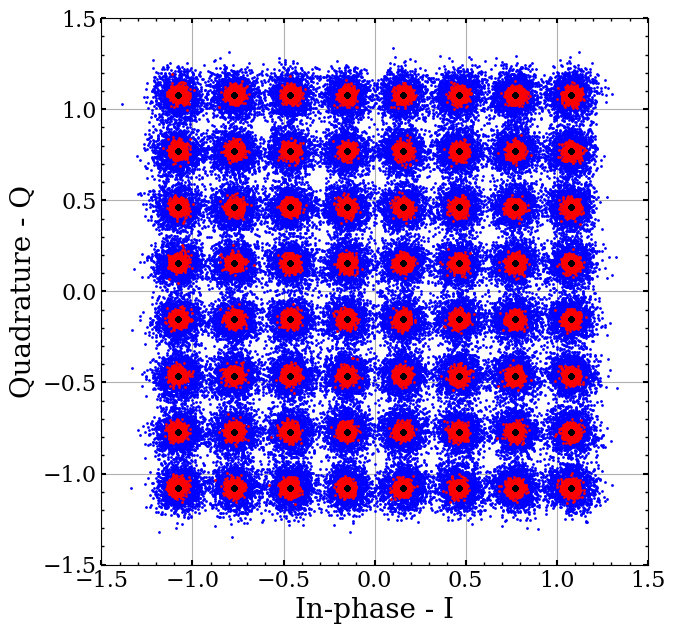

In [44]:
discard = Ni
index = np.arange(0, symbTx.size - discard)
BER, _, SNR = fastBERcalc(symbRx_DPD_ILA[index], symbTx[index], modOrder, modType)

EVM = np.sqrt(calcEVM(symbRx_DPD_ILA[index], modOrder, modType, symbTx[index]))*100

print(f"BER = {BER[0]:.5f} \nSNR = {SNR[0]:.3f} dB \nEVM = {EVM[0]:.3f} %")

# Normalização para o plot
symbTx = pnorm(symbTx)
symbRx_DPD_ILA = pnorm(symbRx_DPD_ILA)

fig, axs = plt.subplots(figsize = (7, 7))
axs.plot(symbRx[index].real, symbRx[index].imag, "o", color = "b", ms = 1, label = "No DPD")
axs.plot(symbRx_DPD_ILA[index].real, symbRx_DPD_ILA[index].imag, "o", color = "r", ms = 1, label = "NN-DPD")
axs.plot(symbTx.real, symbTx.imag, "o", color = "k", ms = 3, label = "SymbTx")
axs.set_ylabel("Quadrature - Q", fontsize = 20)
axs.set_xlabel("In-phase - I", fontsize = 20)
plt.axis("square")

axs.set_xlim(-1.5, 1.5)
axs.set_ylim(-1.5, 1.5)
axs.minorticks_on()
axs.tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs.tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")

plt.grid()
plt.tight_layout()
#plt.savefig("constelacao_nnDPD.png")

In [45]:
freq, P_sigTx            = welch(pnorm(sigTx), fs = SpS_mp*Rs, nfft = 16*1024, return_onesided = False)
freq, P_sigRx_PA         = welch(pnorm(sigRx_PA)[0::SpS//SpS_mp], fs = SpS_mp*Rs, nfft = 16*1024, return_onesided = False)
freq, P_sigRx_PA_DPD_ILA = welch(pnorm(sigRx_PA_DPD_ILA)[0::SpS//SpS_mp], fs = SpS_mp*Rs, nfft = 16*1024, return_onesided = False)

SigTx - ACLR = -34.643 dB
SigRx PA w/o DPD - ACLR = -25.315 dB
SigRx PA w DPD-ILA - ACLR = -31.044 dB


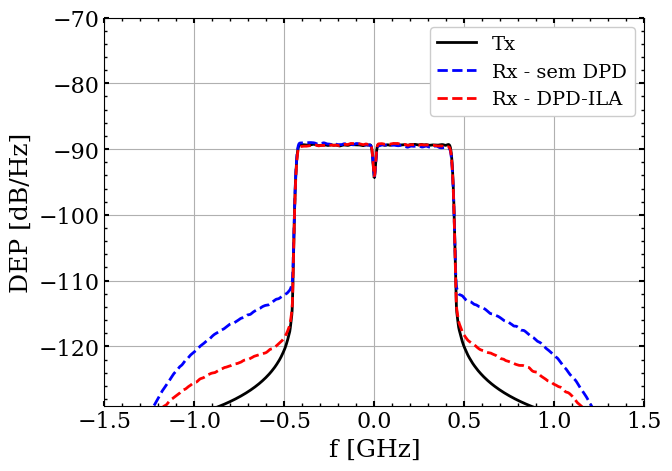

In [46]:
print(f"SigTx - ACLR = {calcACLR(P_sigTx, freq, 0.5e9):.3f} dB")
print(f"SigRx PA w/o DPD - ACLR = {calcACLR(P_sigRx_PA, freq, 0.5e9):.3f} dB")
print(f"SigRx PA w DPD-ILA - ACLR = {calcACLR(P_sigRx_PA_DPD_ILA, freq, 0.5e9):.3f} dB")

fig, axs = plt.subplots(1, 1, figsize = (7, 5))

axs.plot(freq/1e9, 10*np.log10(P_sigTx), lw = 2, color = "k", label = "Tx")
axs.plot(freq/1e9, 10*np.log10(P_sigRx_PA), lw = 2, color = "b", label = "Rx - sem DPD", ls = "--")
axs.plot(freq/1e9, 10*np.log10(P_sigRx_PA_DPD_ILA), lw = 2, color = "r", label = "Rx - DPD-ILA", ls = "--")
axs.set_xlim(-1.5, 1.5)
axs.set_ylim(-129, -70)

axs.set_ylabel("DEP [dB/Hz]", fontsize = 18)
axs.set_xlabel("f [GHz]", fontsize = 18)
axs.legend(framealpha = 1, fontsize = 14, loc = "upper right")

axs.minorticks_on()
axs.tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs.tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")
axs.grid()

plt.tight_layout()
#plt.savefig("sig_freq_mpDPD.pdf")